# Time Restricted Eating and Alzheimer's Disease Staging

## A biomarker driven machine learning analysis using ADNI and CDC healthy aging data

This notebook studies whether a compact set of Time Restricted Eating relevant biomarkers can explain Alzheimer's disease stage almost as well as a much larger clinical feature set.

The workflow is organized as a research notebook. It begins with study motivation and dataset metadata, then moves through exploratory analysis, preprocessing, supervised modeling, model interpretation, patient phenotyping, population level CDC analysis, and a final evidence summary.

## Abstract

Alzheimer's disease progression is linked to changes in cognition, memory, brain structure, glucose metabolism, age, and genetic risk. Time Restricted Eating is biologically relevant because it may influence metabolic regulation, insulin sensitivity, inflammation, and energy utilization.

This analysis uses two complementary datasets. The ADNI dataset provides patient level clinical, cognitive, imaging, and biomarker features for Alzheimer's staging. The CDC healthy aging dataset provides population level context around cognitive decline and nutrition or obesity indicators. The main modeling question is whether a smaller TRE relevant feature set can retain comparable diagnostic signal to a full clinical feature matrix.

## Dataset metadata

| Dataset | Role in notebook | Rows | Columns | Main use |
|---|---:|---:|---:|---|
| ADNI Alzheimer's dataset | Patient level modeling dataset | 1,737 | 371 raw columns | Diagnosis staging, SHAP interpretation, clustering |
| CDC Alzheimer's Disease and Healthy Aging Data | Population level context dataset | 214,462 | 29 raw columns | Cognitive decline and nutrition or obesity trends |

The latest observed run produced five ADNI diagnostic groups: CN, SMC, EMCI, LMCI, and AD. The class distribution showed LMCI as the largest group and SMC as the smallest group, which is important when interpreting macro F1 and class level recall.

## Problem statement

The goal is not only to build a classifier. The goal is to test whether TRE relevant biomarkers preserve most of the diagnostic signal contained in the full clinical dataset.

The main comparison is between two models:

| Model | Feature count | Evaluation target |
|---|---:|---|
| Full feature XGBoost model | 351 | Five class ADNI diagnosis staging |
| TRE feature XGBoost model | 20 | Five class ADNI diagnosis staging |

The latest weighted run showed that the compact TRE feature model can perform at a level comparable to the larger full feature model. This makes the analysis more interpretable because the smaller model is centered on metabolic, cognitive, memory, structural brain, demographic, and genetic features.

## Research questions

1. How are cognitive scores, FDG PET metabolism, brain volumes, memory markers, and ApoE4 risk distributed across diagnosis stages?
2. Can XGBoost classify the five ADNI diagnosis stages using the full feature matrix?
3. How much performance is retained when the model is restricted to TRE relevant features?
4. Which biomarkers drive model decisions according to SHAP?
5. Do TRE relevant features reveal patient phenotype clusters that may reflect different response profiles?
6. Do CDC population indicators provide broader context for diet, obesity, and cognitive decline patterns?

## Table of contents

1. Setup and styling  
2. Load datasets  
3. ADNI exploratory data analysis  
4. Preprocessing  
5. XGBoost classification with class weighting  
6. SHAP interpretation  
7. Patient phenotyping with UMAP and KMeans  
8. CDC population analysis  
9. Final results summary

In [1]:
# SECTION 1: SETUP AND STYLING

import subprocess
subprocess.run(
    ["pip", "install", "shap", "umap-learn", "-q", "--upgrade"],
    capture_output=True
)

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Patch

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.cluster import KMeans
from sklearn.utils.class_weight import compute_sample_weight

import xgboost as xgb
import shap
import umap

warnings.filterwarnings("ignore")

OUTPUT_DIR = "/kaggle/working/outputs"
FIG_DIR = f"{OUTPUT_DIR}/figures"
MODEL_DIR = f"{OUTPUT_DIR}/models"
DATA_DIR = f"{OUTPUT_DIR}/data"

for folder in [FIG_DIR, MODEL_DIR, DATA_DIR]:
    os.makedirs(folder, exist_ok=True)

DIAG_ORDER = ["CN", "SMC", "EMCI", "LMCI", "AD"]

C_DIAG = {
    "CN": "#2A9D8F",
    "SMC": "#8BD3C7",
    "EMCI": "#E9C46A",
    "LMCI": "#F4A261",
    "AD": "#E76F51",
}

C_SEQ = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#457B9D"]
BG = "white"
TEXT = "#1F2937"

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "axes.labelcolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "text.color": TEXT,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.grid": False,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
})

def clean_axis(ax):
    ax.set_facecolor("white")
    ax.grid(False)
    ax.tick_params(axis="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

def clean_figure(fig):
    for ax in fig.axes:
        clean_axis(ax)

def save_fig(name, fig=None, dpi=220):
    if fig is None:
        fig = plt.gcf()
    clean_figure(fig)
    path = f"{FIG_DIR}/{name}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()

def add_bar_labels(ax, fmt="{:.0f}", padding=3):
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            labels.append(fmt.format(value))
        ax.bar_label(container, labels=labels, padding=padding, fontsize=9)

def grouped_values(df, group_col, value_col, order):
    return [df.loc[df[group_col] == label, value_col].dropna().values for label in order]

2026-05-04 03:41:41.595238: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777866101.798421      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777866101.855869      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777866102.327742      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777866102.327786      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777866102.327789      22 computation_placer.cc:177] computation placer alr

## 1. Load datasets

The notebook loads the patient level ADNI dataset and the CDC population level healthy aging dataset from Kaggle input paths. The printed shapes are used as a first sanity check before analysis.

In [2]:
# SECTION 2: LOAD DATASETS

PATH_CDC = (
    "/kaggle/input/datasets/ananthu19/alzheimer-disease-and-healthy-aging-data-in-us/"
    "Alzheimer Disease and Healthy Aging Data In US.csv"
)
PATH_ADNI = "/kaggle/input/datasets/sarthakkanjariya/alzheimer-dataset/Alzheimer_DataSet.csv"

df_cdc = pd.read_csv(PATH_CDC, low_memory=False)
df_adni = pd.read_csv(PATH_ADNI)

print(f"CDC  → {df_cdc.shape[0]:>7,} rows × {df_cdc.shape[1]:>3} cols")
print(f"ADNI → {df_adni.shape[0]:>7,} rows × {df_adni.shape[1]:>3} cols")

print("\nADNI Diagnosis distribution:")
print(df_adni["Diagnosis"].value_counts())

CDC  → 214,462 rows ×  29 cols
ADNI →   1,737 rows × 371 cols

ADNI Diagnosis distribution:
Diagnosis
LMCI    562
CN      417
AD      342
EMCI    310
SMC     106
Name: count, dtype: int64


## 2. ADNI exploratory data analysis

This section visualizes the main clinical and biological signals before modeling. The focus is on diagnosis distribution, cognitive scales, FDG PET metabolism, brain volumes, ApoE4 genetic risk, memory performance, and feature correlations.

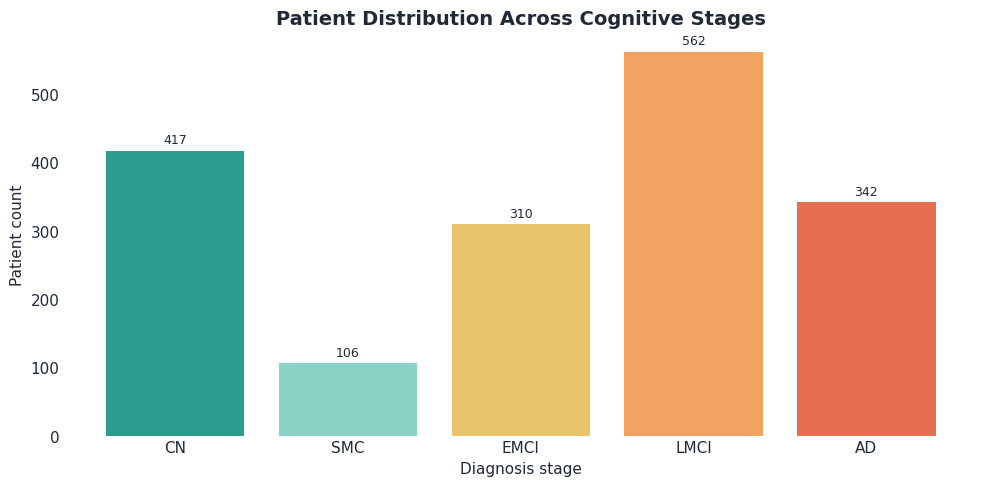

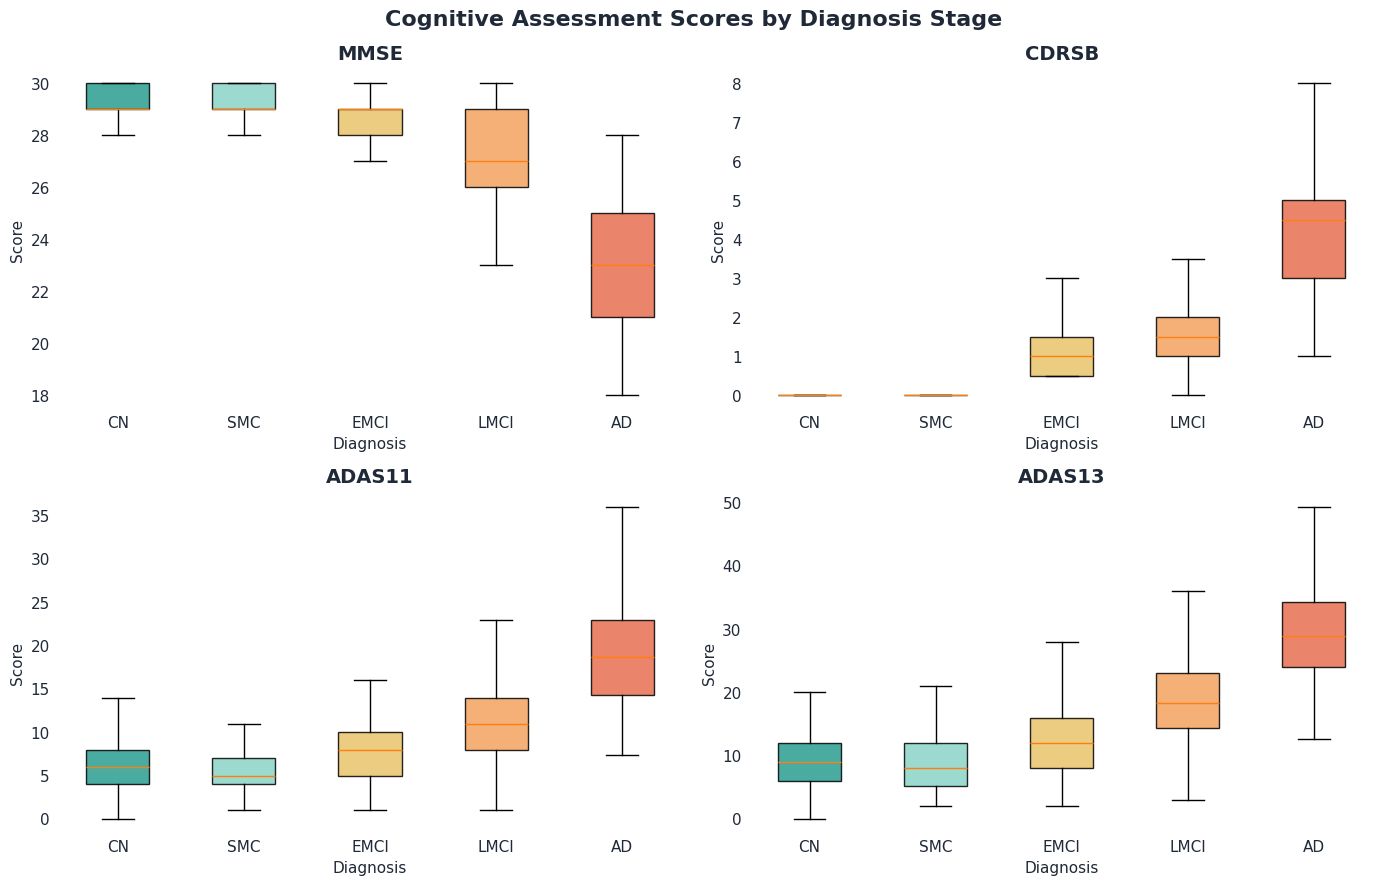

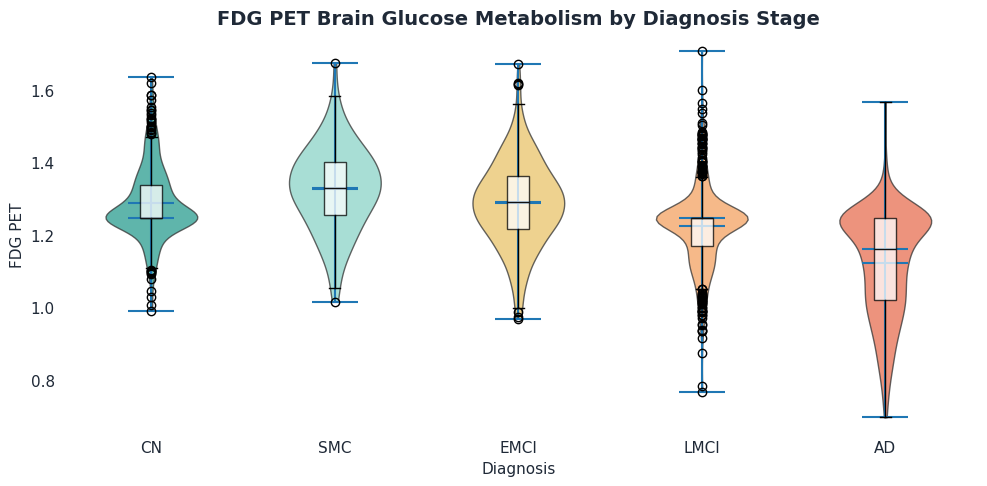

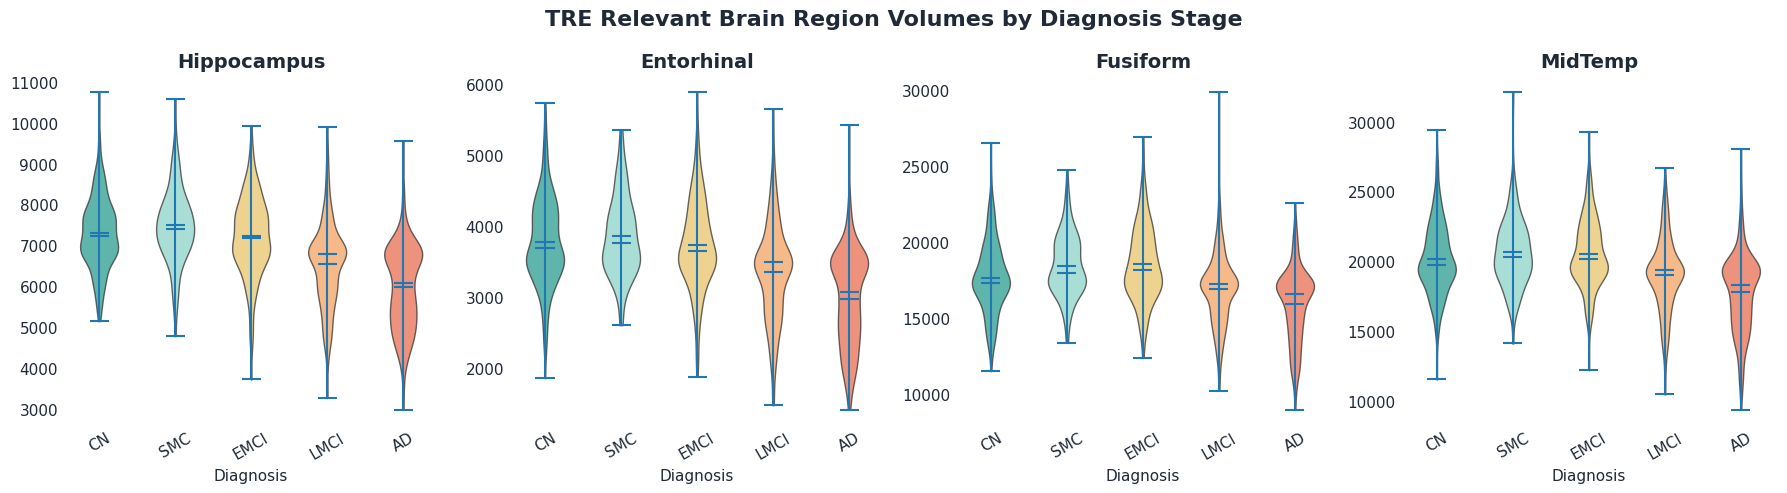

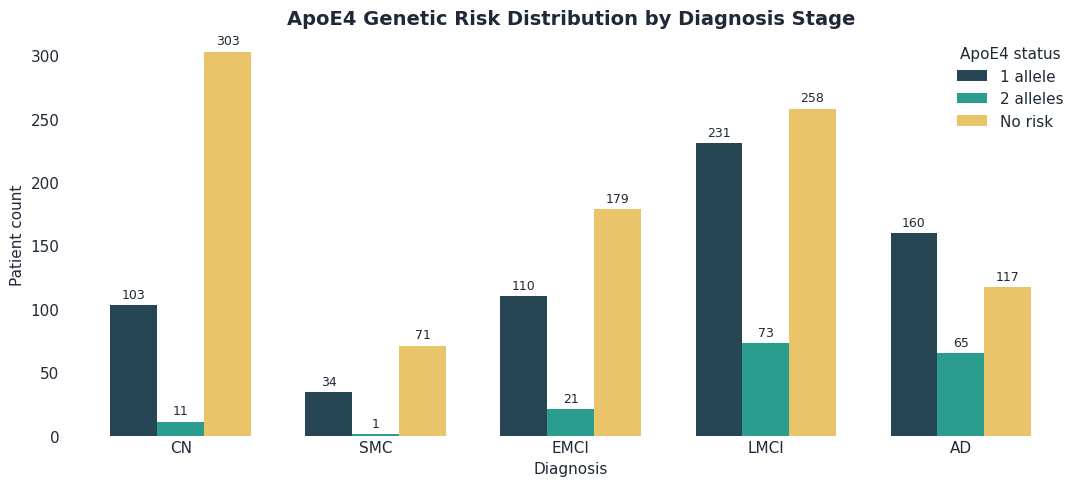

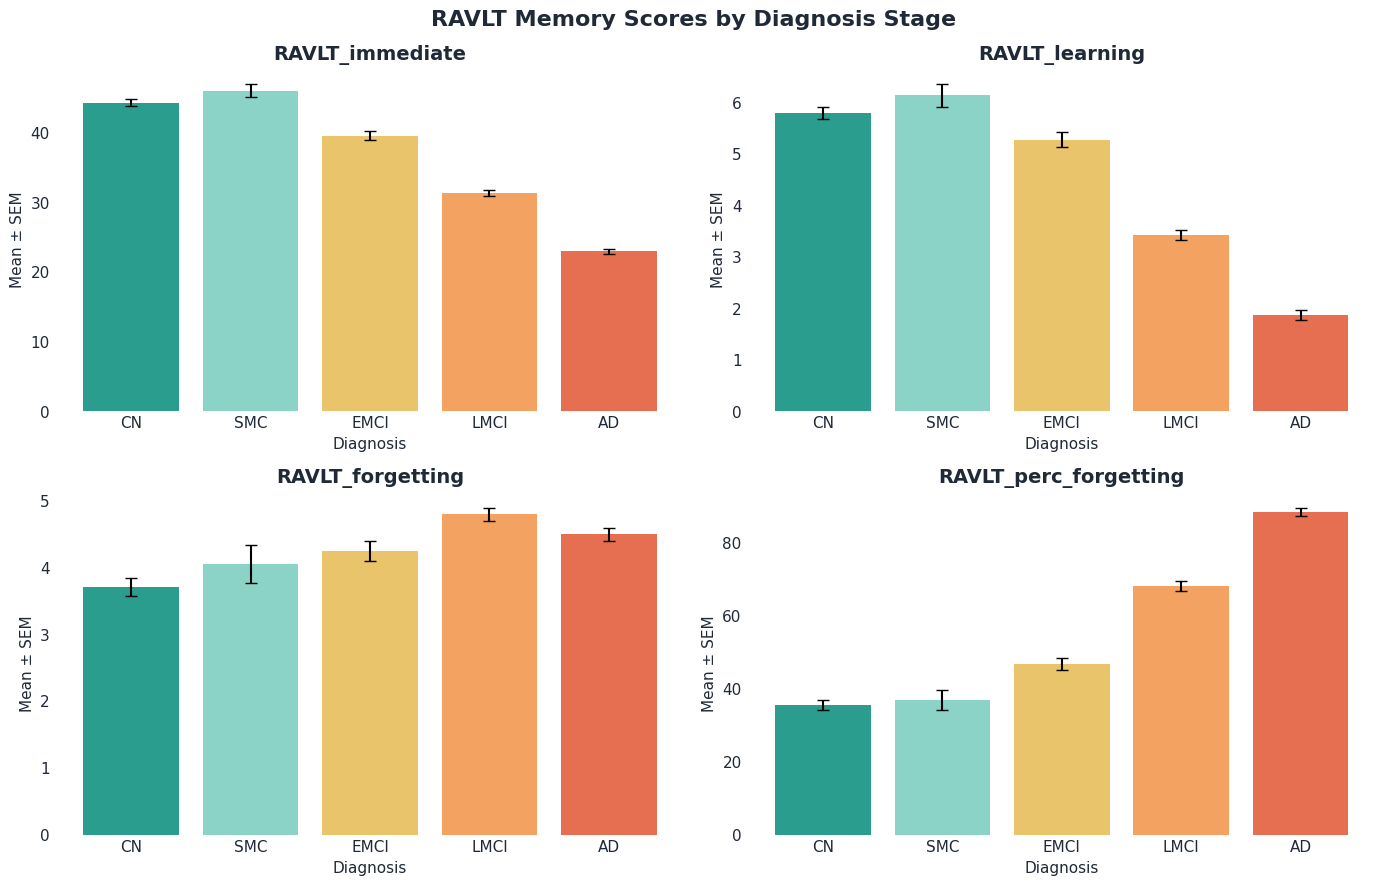

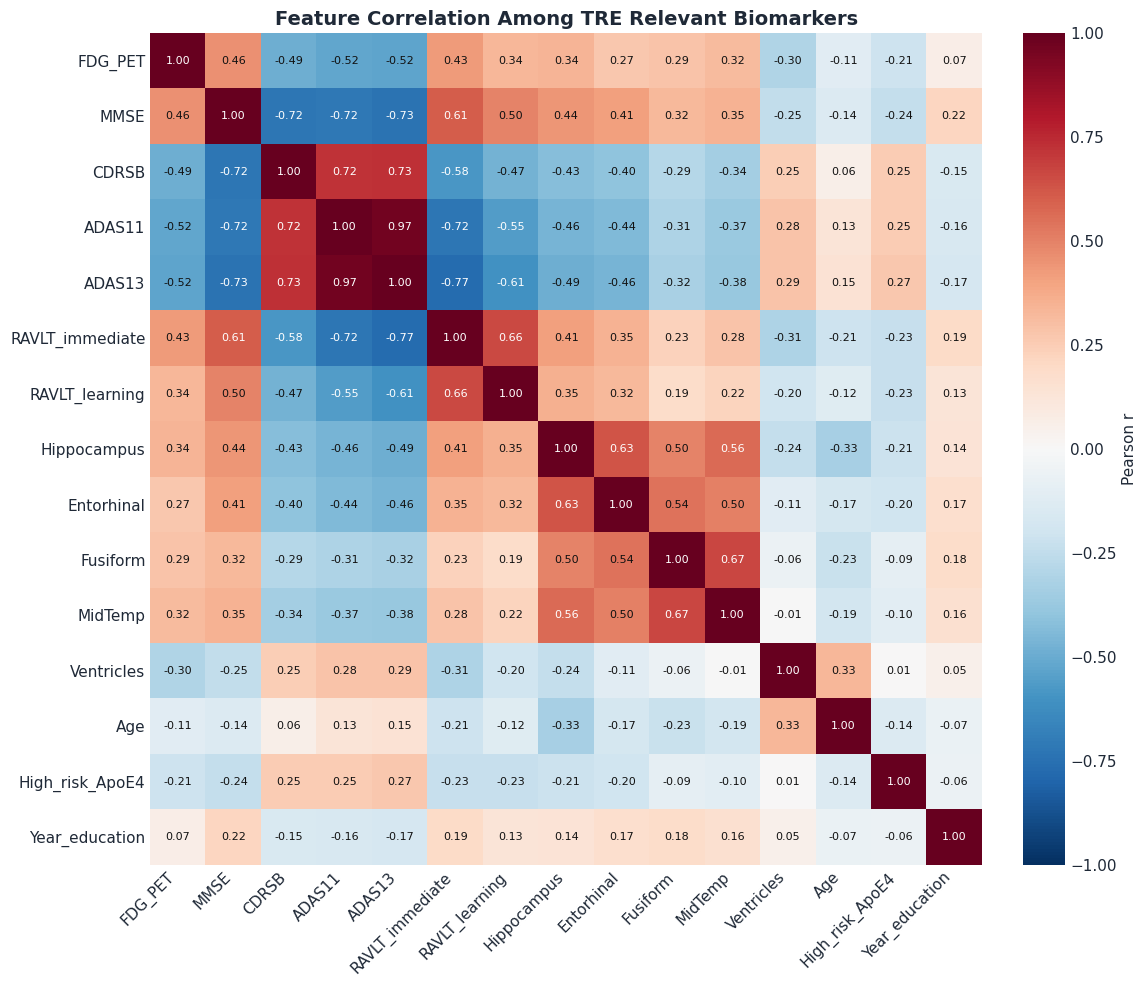

In [3]:
# SECTION 3: ADNI EXPLORATORY DATA ANALYSIS

df_adni["Diagnosis"] = pd.Categorical(
    df_adni["Diagnosis"],
    categories=DIAG_ORDER,
    ordered=True
)
df_adni = df_adni.sort_values("Diagnosis").reset_index(drop=True)

# 3.1 Diagnosis distribution
counts = df_adni["Diagnosis"].value_counts().reindex(DIAG_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values, color=[C_DIAG[d] for d in counts.index], edgecolor="none")
ax.set_title("Patient Distribution Across Cognitive Stages")
ax.set_xlabel("Diagnosis stage")
ax.set_ylabel("Patient count")
add_bar_labels(ax)
save_fig("01_diagnosis_distribution", fig)

# 3.2 Cognitive scores by diagnosis
cog_cols = ["MMSE", "CDRSB", "ADAS11", "ADAS13"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, col in zip(axes, cog_cols):
    data = grouped_values(df_adni, "Diagnosis", col, DIAG_ORDER)
    bp = ax.boxplot(data, labels=DIAG_ORDER, patch_artist=True, showfliers=False)
    for patch, diag in zip(bp["boxes"], DIAG_ORDER):
        patch.set_facecolor(C_DIAG[diag])
        patch.set_alpha(0.85)
    ax.set_title(col)
    ax.set_xlabel("Diagnosis")
    ax.set_ylabel("Score")

fig.suptitle("Cognitive Assessment Scores by Diagnosis Stage", fontsize=16, fontweight="bold")
save_fig("02_cognitive_scores_by_diagnosis", fig)

# 3.3 FDG PET by diagnosis
fig, ax = plt.subplots(figsize=(10, 5))
fdg_data = grouped_values(df_adni, "Diagnosis", "FDG_PET", DIAG_ORDER)

violins = ax.violinplot(fdg_data, showmeans=True, showmedians=True)
for body, diag in zip(violins["bodies"], DIAG_ORDER):
    body.set_facecolor(C_DIAG[diag])
    body.set_edgecolor("#333333")
    body.set_alpha(0.75)

ax.boxplot(fdg_data, positions=np.arange(1, len(DIAG_ORDER) + 1), widths=0.12, patch_artist=True,
           boxprops=dict(facecolor="white", alpha=0.75),
           medianprops=dict(color="#111111"))
ax.set_xticks(np.arange(1, len(DIAG_ORDER) + 1))
ax.set_xticklabels(DIAG_ORDER)
ax.set_title("FDG PET Brain Glucose Metabolism by Diagnosis Stage")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("FDG PET")
save_fig("03_fdgpet_by_diagnosis", fig)

# 3.4 TRE relevant brain volumes
brain_cols = ["Hippocampus", "Entorhinal", "Fusiform", "MidTemp"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, brain_cols):
    data = grouped_values(df_adni, "Diagnosis", col, DIAG_ORDER)
    violins = ax.violinplot(data, showmeans=True, showmedians=True)
    for body, diag in zip(violins["bodies"], DIAG_ORDER):
        body.set_facecolor(C_DIAG[diag])
        body.set_edgecolor("#333333")
        body.set_alpha(0.75)
    ax.set_xticks(np.arange(1, len(DIAG_ORDER) + 1))
    ax.set_xticklabels(DIAG_ORDER, rotation=30)
    ax.set_title(col)
    ax.set_xlabel("Diagnosis")

fig.suptitle("TRE Relevant Brain Region Volumes by Diagnosis Stage", fontsize=16, fontweight="bold")
save_fig("04_brain_volumes_by_diagnosis", fig)

# 3.5 ApoE4 genetic risk by stage
apoe_data = (
    df_adni.groupby(["Diagnosis", "High_risk_ApoE4"], observed=True)
    .size()
    .reset_index(name="count")
)
apoe_data["ApoE4_label"] = apoe_data["High_risk_ApoE4"].map({
    0.0: "No risk",
    1.0: "1 allele",
    2.0: "2 alleles",
})

pivot = (
    apoe_data.pivot_table(
        index="Diagnosis",
        columns="ApoE4_label",
        values="count",
        fill_value=0,
        observed=True
    )
    .reindex(DIAG_ORDER)
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(pivot.index))
width = 0.24

for i, col in enumerate(pivot.columns):
    ax.bar(x + (i - 1) * width, pivot[col].values, width=width, label=col, color=C_SEQ[i])

ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_title("ApoE4 Genetic Risk Distribution by Diagnosis Stage")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Patient count")
ax.legend(title="ApoE4 status")
add_bar_labels(ax)
save_fig("05_apoe4_by_diagnosis", fig)

# 3.6 RAVLT memory performance
ravlt_cols = ["RAVLT_immediate", "RAVLT_learning", "RAVLT_forgetting", "RAVLT_perc_forgetting"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, col in zip(axes, ravlt_cols):
    means = df_adni.groupby("Diagnosis", observed=True)[col].mean().reindex(DIAG_ORDER)
    sems = df_adni.groupby("Diagnosis", observed=True)[col].sem().reindex(DIAG_ORDER)
    ax.bar(means.index, means.values, yerr=sems.values, capsize=4,
           color=[C_DIAG[d] for d in means.index], edgecolor="none")
    ax.set_title(col)
    ax.set_xlabel("Diagnosis")
    ax.set_ylabel("Mean ± SEM")

fig.suptitle("RAVLT Memory Scores by Diagnosis Stage", fontsize=16, fontweight="bold")
save_fig("06_ravlt_memory_scores", fig)

# 3.7 Correlation heatmap
tre_corr_cols = [
    "FDG_PET", "MMSE", "CDRSB", "ADAS11", "ADAS13",
    "RAVLT_immediate", "RAVLT_learning",
    "Hippocampus", "Entorhinal", "Fusiform", "MidTemp",
    "Ventricles", "Age", "High_risk_ApoE4", "Year_education"
]
tre_corr_cols = [col for col in tre_corr_cols if col in df_adni.columns]

corr = df_adni[tre_corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Feature Correlation Among TRE Relevant Biomarkers")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        value = corr.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > 0.55 else "#111111")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson r")
save_fig("07_correlation_heatmap", fig)

## 3. Preprocessing

The ADNI table is prepared for modeling by removing unused columns, encoding categorical variables, defining the diagnosis target, and building two feature matrices: the full feature matrix and the smaller TRE relevant feature matrix.

In [4]:
# SECTION 4: PREPROCESSING

null_cols = df_adni.columns[df_adni.isnull().all()].tolist()
drop_cols = null_cols + ["RID", "Test_data"]
drop_cols = [col for col in drop_cols if col in df_adni.columns]

df = df_adni.drop(columns=drop_cols).copy()

cat_cols = ["Gender", "Ethnicity", "Race", "Marital_status"]
cat_cols = [col for col in cat_cols if col in df.columns]

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

diag_map = {"CN": 0, "SMC": 1, "EMCI": 2, "LMCI": 3, "AD": 4}

y = df["Diagnosis"].map(diag_map).values.astype(int)
X_df = df.drop(columns=["Diagnosis"])
feature_names = X_df.columns.tolist()
X = X_df.values

TRE_FEATURES = [
    "FDG_PET", "MMSE", "CDRSB", "ADAS11", "ADAS13",
    "RAVLT_immediate", "RAVLT_learning", "RAVLT_forgetting", "RAVLT_perc_forgetting",
    "Hippocampus", "Entorhinal", "Fusiform", "MidTemp",
    "Ventricles", "WholeBrain", "Intra cranial volume",
    "Age", "High_risk_ApoE4", "Year_education",
    "Gender"
]
TRE_FEATURES = [f for f in TRE_FEATURES if f in df.columns]
X_tre = df[TRE_FEATURES].values

scaler_full = StandardScaler()
scaler_tre = StandardScaler()

X_scaled = scaler_full.fit_transform(X)
X_tre_scaled = scaler_tre.fit_transform(X_tre)

print(f"Full feature matrix: {X.shape}")
print(f"TRE feature matrix:  {X_tre.shape}")
print(f"Class distribution:  {pd.Series(y).value_counts().sort_index().to_dict()}")

Full feature matrix: (1737, 351)
TRE feature matrix:  (1737, 20)
Class distribution:  {0: 417, 1: 106, 2: 310, 3: 562, 4: 342}


## 4. XGBoost classification with class weighting

The SMC class is the smallest group and overlaps clinically with normal aging. Class weighting is included so that the training objective is less dominated by larger classes. Macro F1 is used because it gives equal importance to each diagnosis group.

Training device: cuda
  Fold 1  |  Macro F1: 0.6770
  Fold 2  |  Macro F1: 0.6724
  Fold 3  |  Macro F1: 0.7051
  Fold 4  |  Macro F1: 0.6766
  Fold 5  |  Macro F1: 0.6719

5-Fold CV Macro F1: 0.6806 ± 0.0124

Test Accuracy: 0.7960  |  Test Macro F1: 0.6734

Classification Report:
              precision    recall  f1-score   support

          CN       0.80      0.93      0.86        84
         SMC       0.25      0.05      0.08        21
        EMCI       0.73      0.76      0.75        62
        LMCI       0.78      0.83      0.81       113
          AD       0.92      0.84      0.88        68

    accuracy                           0.80       348
   macro avg       0.70      0.68      0.67       348
weighted avg       0.77      0.80      0.78       348



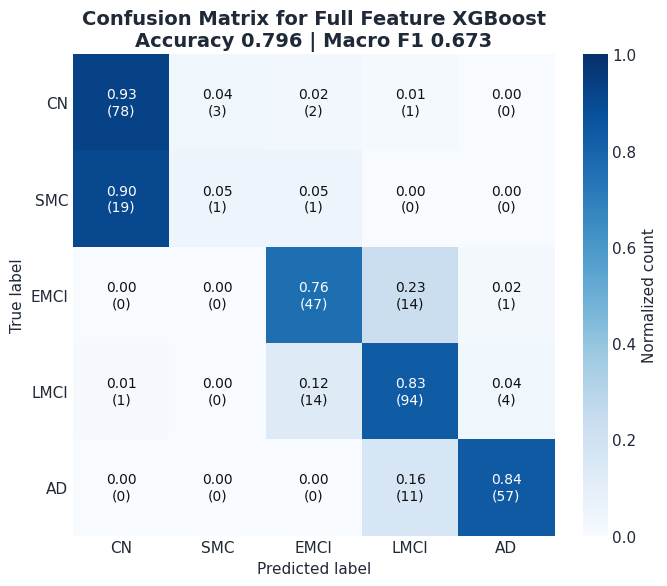

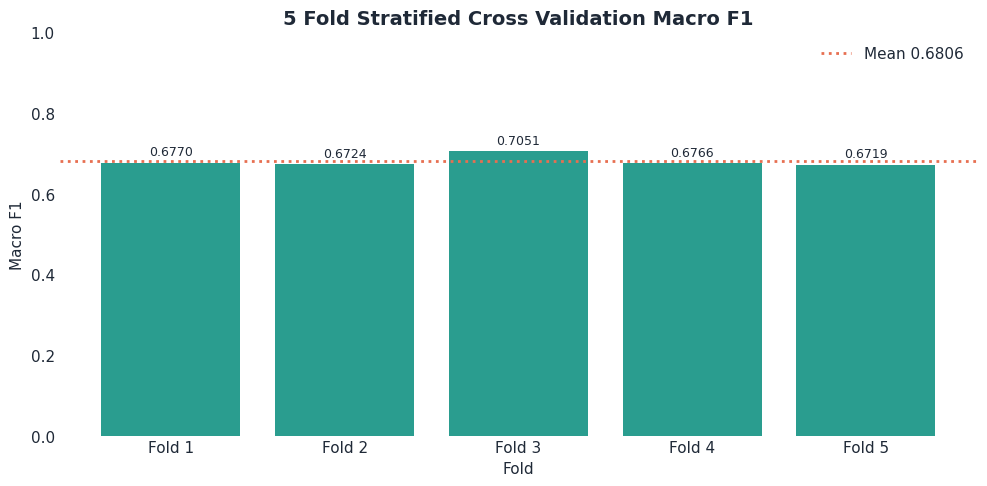

In [5]:
# SECTION 5: CLASSIFICATION WITH CLASS WEIGHTING

indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

X_tre_train, X_tre_test = X_tre[train_idx], X_tre[test_idx]

try:
    result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
    device = "cuda" if result.returncode == 0 else "cpu"
except Exception:
    device = "cpu"

print(f"Training device: {device}")

def make_xgb_model(n_estimators=500, learning_rate=0.05, max_depth=6):
    return xgb.XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric="mlogloss",
        device=device,
        random_state=42,
        n_jobs=-1,
    )

model = make_xgb_model(n_estimators=500, learning_rate=0.05, max_depth=6)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
    fold_model = make_xgb_model(n_estimators=500, learning_rate=0.05, max_depth=6)
    fold_weights = compute_sample_weight("balanced", y_train[tr_idx])

    fold_model.fit(
        X_train[tr_idx],
        y_train[tr_idx],
        sample_weight=fold_weights,
        eval_set=[(X_train[val_idx], y_train[val_idx])],
        verbose=False,
    )

    preds = fold_model.predict(X_train[val_idx])
    score = f1_score(y_train[val_idx], preds, average="macro")
    cv_scores.append(score)
    print(f"  Fold {fold}  |  Macro F1: {score:.4f}")

print(f"\n5-Fold CV Macro F1: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

weights = compute_sample_weight("balanced", y_train)

model.fit(
    X_train,
    y_train,
    sample_weight=weights,
    verbose=False,
)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print(f"\nTest Accuracy: {acc:.4f}  |  Test Macro F1: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=DIAG_ORDER))

model.save_model(f"{MODEL_DIR}/xgb_adni_fullfeature.json")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(np.arange(len(DIAG_ORDER)))
ax.set_yticks(np.arange(len(DIAG_ORDER)))
ax.set_xticklabels(DIAG_ORDER)
ax.set_yticklabels(DIAG_ORDER)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Confusion Matrix for Full Feature XGBoost\nAccuracy {acc:.3f} | Macro F1 {f1:.3f}")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}\n({cm[i, j]})",
                ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "#111111",
                fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Normalized count")
save_fig("08_confusion_matrix", fig)

# Cross validation score plot
fig, ax = plt.subplots(figsize=(10, 5))
x_labels = [f"Fold {i}" for i in range(1, 6)]
ax.bar(x_labels, cv_scores, color="#2A9D8F", edgecolor="none")
ax.axhline(np.mean(cv_scores), color="#E76F51", linestyle=":", linewidth=2,
           label=f"Mean {np.mean(cv_scores):.4f}")
ax.set_ylim(0, 1)
ax.set_title("5 Fold Stratified Cross Validation Macro F1")
ax.set_xlabel("Fold")
ax.set_ylabel("Macro F1")
ax.legend()
add_bar_labels(ax, fmt="{:.4f}")
save_fig("09_cv_scores", fig)

## 5. SHAP interpretation

SHAP is used to identify the features that most influence the trained XGBoost model. This cell uses a robust handler for multiple SHAP output formats, including the older list format and the newer 3D multiclass format.

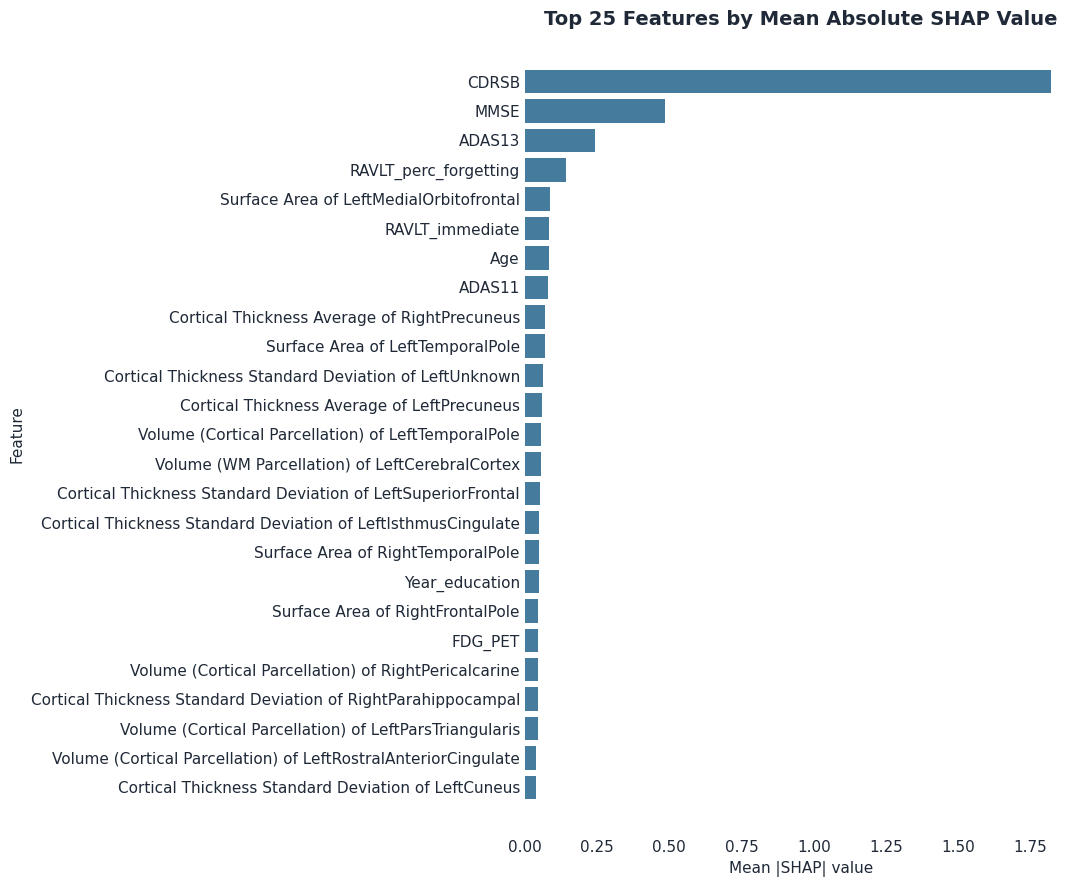

TRE-Feature Model Macro F1: 0.6858


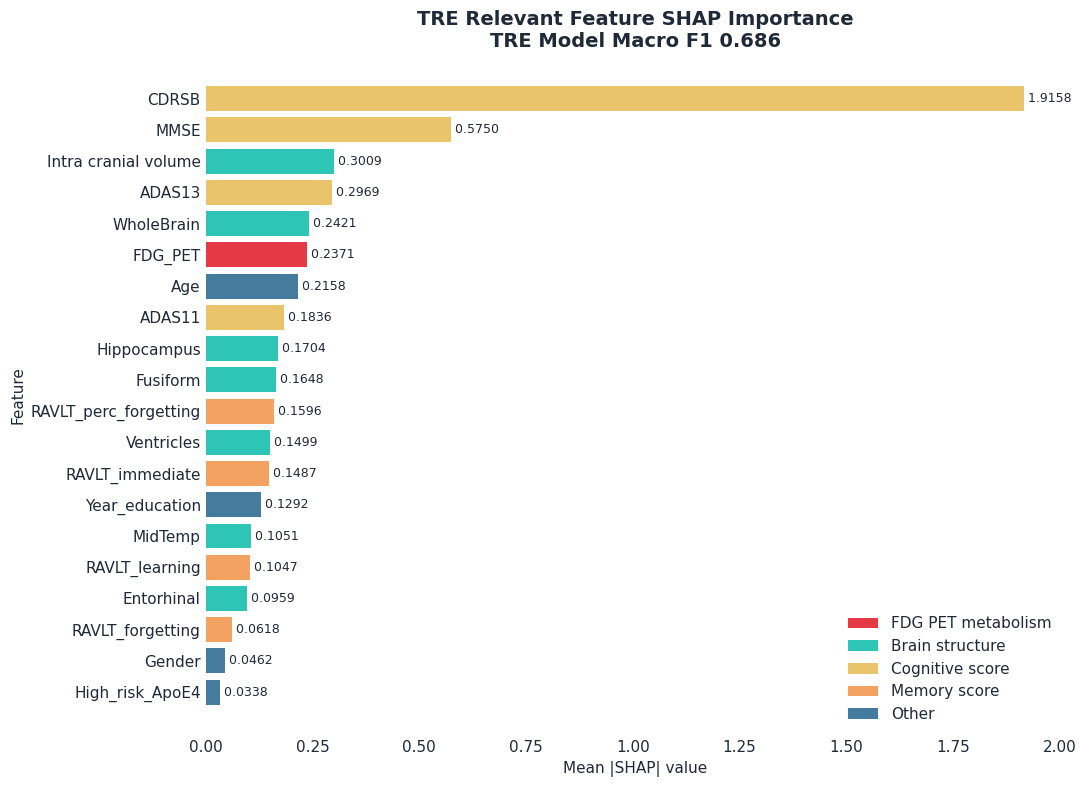

In [6]:
# SECTION 6: SHAP ANALYSIS

feature_names = df.drop(columns=["Diagnosis"]).columns.tolist()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Robust handler for all SHAP output formats
if isinstance(shap_values, list):
    mean_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
elif shap_values.ndim == 3:
    mean_shap = np.abs(shap_values).mean(axis=(0, 2))
else:
    mean_shap = np.abs(shap_values).mean(axis=0)

assert len(mean_shap) == len(feature_names), (
    f"Shape mismatch: mean_shap={len(mean_shap)}, features={len(feature_names)}"
)

shap_df = pd.DataFrame({"feature": feature_names, "mean_shap": mean_shap})
shap_df = shap_df.sort_values("mean_shap", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(shap_df["feature"], shap_df["mean_shap"], color="#457B9D")
ax.invert_yaxis()
ax.set_title("Top 25 Features by Mean Absolute SHAP Value")
ax.set_xlabel("Mean |SHAP| value")
ax.set_ylabel("Feature")
save_fig("10_shap_global_importance", fig)

# TRE feature model
model_tre = make_xgb_model(n_estimators=400, learning_rate=0.05, max_depth=5)

model_tre.fit(
    X_tre_train,
    y_train,
    sample_weight=weights,
    verbose=False,
)

y_pred_tre = model_tre.predict(X_tre_test)
f1_tre = f1_score(y_test, y_pred_tre, average="macro")

print(f"TRE-Feature Model Macro F1: {f1_tre:.4f}")

model_tre.save_model(f"{MODEL_DIR}/xgb_adni_trefeature.json")

explainer_tre = shap.TreeExplainer(model_tre)
shap_tre = explainer_tre.shap_values(X_tre_test)

if isinstance(shap_tre, list):
    mean_shap_tre = np.mean([np.abs(sv) for sv in shap_tre], axis=0).mean(axis=0)
elif shap_tre.ndim == 3:
    mean_shap_tre = np.abs(shap_tre).mean(axis=(0, 2))
else:
    mean_shap_tre = np.abs(shap_tre).mean(axis=0)

assert len(mean_shap_tre) == len(TRE_FEATURES), (
    f"Shape mismatch: mean_shap_tre={len(mean_shap_tre)}, TRE_FEATURES={len(TRE_FEATURES)}"
)

shap_tre_df = pd.DataFrame({"feature": TRE_FEATURES, "mean_shap": mean_shap_tre})
shap_tre_df = shap_tre_df.sort_values("mean_shap", ascending=False)

def get_mechanism(feat):
    if feat == "FDG_PET":
        return "#E63946"
    if feat in [
        "Hippocampus", "Entorhinal", "Fusiform", "MidTemp",
        "Ventricles", "WholeBrain", "Intra cranial volume"
    ]:
        return "#2EC4B6"
    if feat in ["MMSE", "CDRSB", "ADAS11", "ADAS13"]:
        return "#E9C46A"
    if "RAVLT" in feat:
        return "#F4A261"
    return "#457B9D"

colors = [get_mechanism(f) for f in shap_tre_df["feature"]]

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(shap_tre_df["feature"], shap_tre_df["mean_shap"], color=colors)
ax.invert_yaxis()
ax.set_title(f"TRE Relevant Feature SHAP Importance\nTRE Model Macro F1 {f1_tre:.3f}")
ax.set_xlabel("Mean |SHAP| value")
ax.set_ylabel("Feature")

legend_items = [
    Patch(facecolor="#E63946", label="FDG PET metabolism"),
    Patch(facecolor="#2EC4B6", label="Brain structure"),
    Patch(facecolor="#E9C46A", label="Cognitive score"),
    Patch(facecolor="#F4A261", label="Memory score"),
    Patch(facecolor="#457B9D", label="Other"),
]
ax.legend(handles=legend_items, loc="lower right")

for i, value in enumerate(shap_tre_df["mean_shap"]):
    ax.text(value, i, f" {value:.4f}", va="center", fontsize=9)

save_fig("11_shap_tre_features", fig)

## 6. Patient phenotyping with UMAP and KMeans

The TRE feature matrix is projected into two dimensions using UMAP and clustered with KMeans. These clusters are interpreted as metabolic cognitive phenotypes that may be useful for future TRE responder hypotheses.

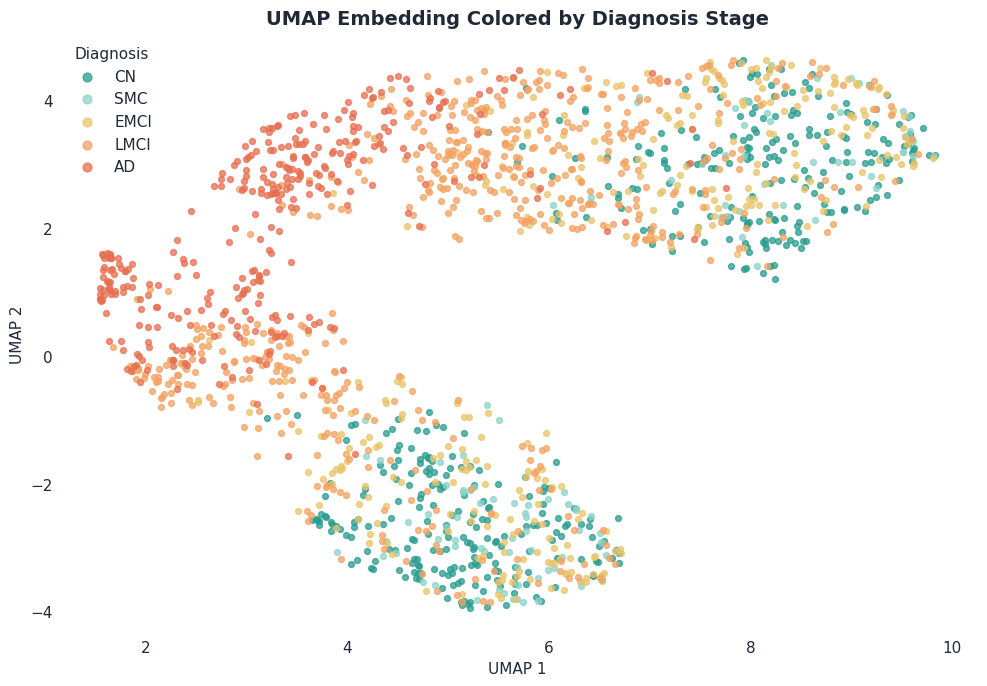

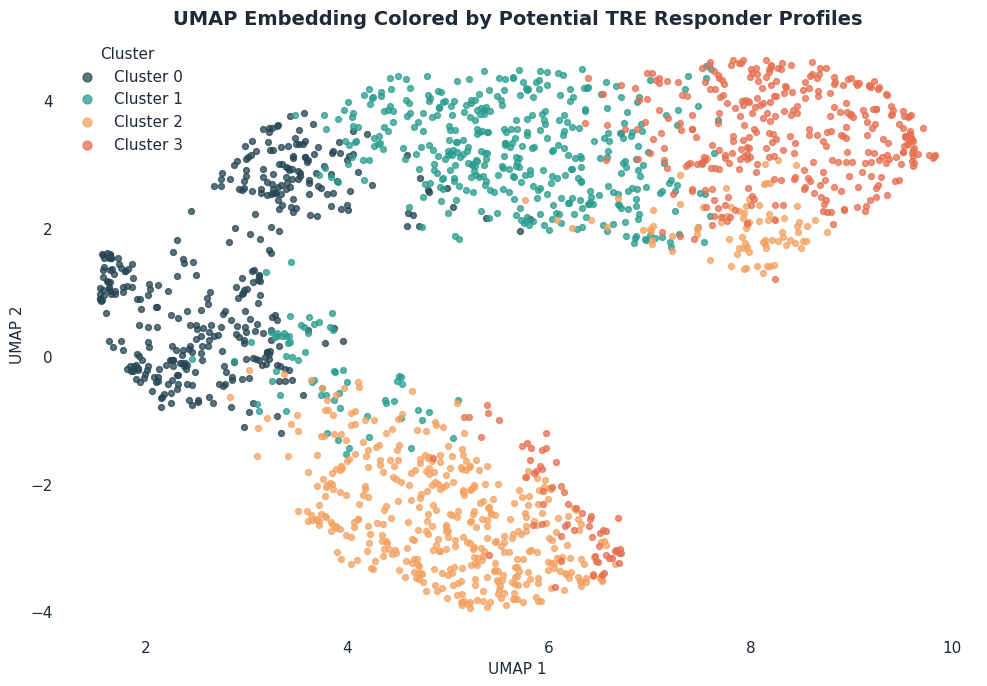

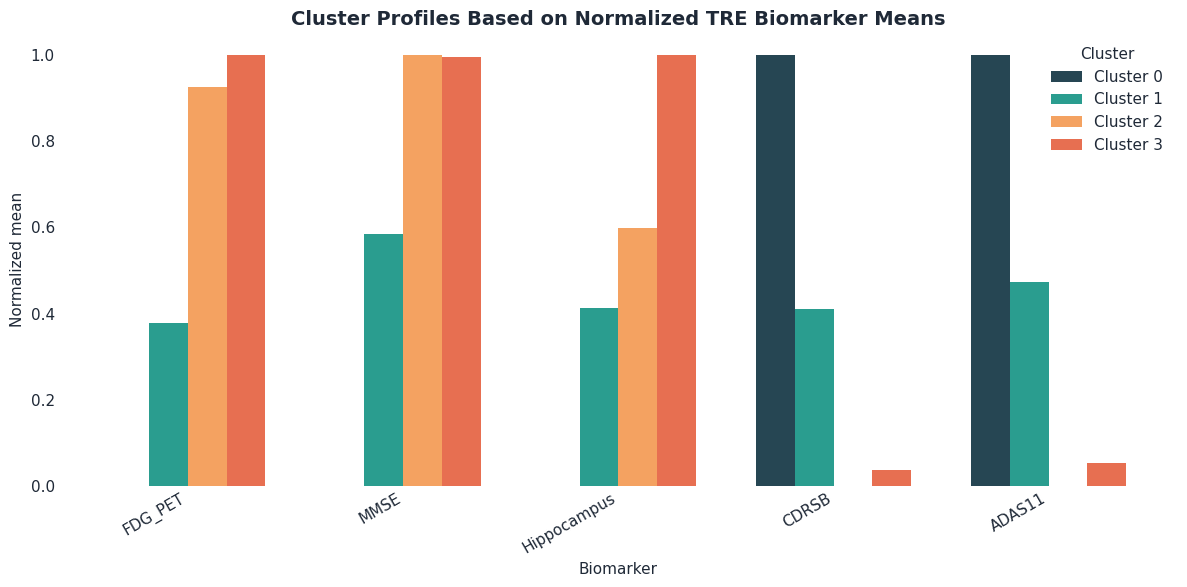

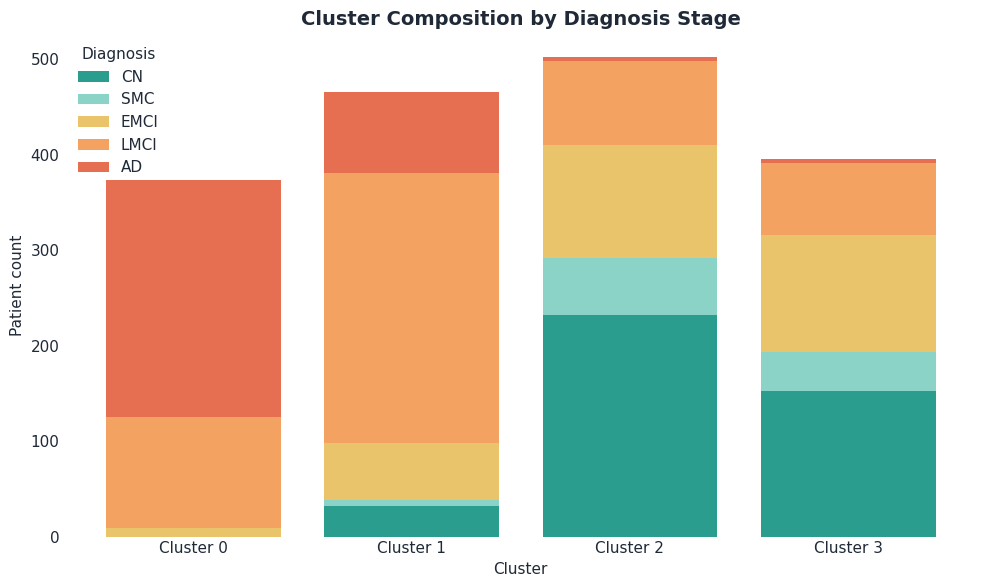

In [7]:
# SECTION 7: PATIENT PHENOTYPING

reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1,
)

embedding = reducer.fit_transform(X_tre_scaled)

N_CLUSTERS = 4
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
cluster_labels = km.fit_predict(X_tre_scaled)

cluster_df = pd.DataFrame({
    "UMAP1": embedding[:, 0],
    "UMAP2": embedding[:, 1],
    "Cluster": [f"Cluster {c}" for c in cluster_labels],
    "Diagnosis": df_adni["Diagnosis"].astype(str).values,
    "FDG_PET": df["FDG_PET"].values if "FDG_PET" in df.columns else np.nan,
    "MMSE": df["MMSE"].values if "MMSE" in df.columns else np.nan,
    "Hippocampus": df["Hippocampus"].values if "Hippocampus" in df.columns else np.nan,
})

# UMAP colored by diagnosis
fig, ax = plt.subplots(figsize=(10, 7))
for diag in DIAG_ORDER:
    subset = cluster_df[cluster_df["Diagnosis"] == diag]
    ax.scatter(subset["UMAP1"], subset["UMAP2"],
               s=18, alpha=0.75, color=C_DIAG[diag], label=diag)

ax.set_title("UMAP Embedding Colored by Diagnosis Stage")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(title="Diagnosis", markerscale=1.5)
save_fig("12_umap_by_diagnosis", fig)

# UMAP colored by cluster
cluster_palette = ["#264653", "#2A9D8F", "#F4A261", "#E76F51"]

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(N_CLUSTERS):
    label = f"Cluster {i}"
    subset = cluster_df[cluster_df["Cluster"] == label]
    ax.scatter(subset["UMAP1"], subset["UMAP2"],
               s=18, alpha=0.75, color=cluster_palette[i], label=label)

ax.set_title("UMAP Embedding Colored by Potential TRE Responder Profiles")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(title="Cluster", markerscale=1.5)
save_fig("13_umap_by_cluster", fig)

# Cluster biomarker profiles
profile_cols = ["FDG_PET", "MMSE", "Hippocampus", "CDRSB", "ADAS11"]
profile_cols = [c for c in profile_cols if c in df.columns]

cluster_profile_df = df[profile_cols].copy()
cluster_profile_df["Cluster"] = [f"Cluster {c}" for c in cluster_labels]

profile = cluster_profile_df.groupby("Cluster")[profile_cols].mean()

profile_norm = profile.copy()
for col in profile_cols:
    mn = profile_norm[col].min()
    mx = profile_norm[col].max()
    denom = mx - mn if mx != mn else 1
    profile_norm[col] = (profile_norm[col] - mn) / denom

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(profile_cols))
width = 0.18

for i, cluster in enumerate(profile_norm.index):
    ax.bar(x + (i - 1.5) * width, profile_norm.loc[cluster].values,
           width=width, label=cluster, color=cluster_palette[i])

ax.set_xticks(x)
ax.set_xticklabels(profile_cols, rotation=30, ha="right")
ax.set_title("Cluster Profiles Based on Normalized TRE Biomarker Means")
ax.set_xlabel("Biomarker")
ax.set_ylabel("Normalized mean")
ax.legend(title="Cluster")
save_fig("14_cluster_profiles", fig)

# Cluster composition by diagnosis
comp = (
    cluster_df.groupby(["Cluster", "Diagnosis"])
    .size()
    .reset_index(name="count")
)

comp_pivot = (
    comp.pivot_table(index="Cluster", columns="Diagnosis", values="count", fill_value=0)
    .reindex(columns=DIAG_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(comp_pivot.index))

for diag in DIAG_ORDER:
    values = comp_pivot[diag].values
    ax.bar(comp_pivot.index, values, bottom=bottom, color=C_DIAG[diag], label=diag)
    bottom += values

ax.set_title("Cluster Composition by Diagnosis Stage")
ax.set_xlabel("Cluster")
ax.set_ylabel("Patient count")
ax.legend(title="Diagnosis")
save_fig("15_cluster_diagnosis_composition", fig)

cluster_df.to_csv(f"{DATA_DIR}/patient_clusters.csv", index=False)

## 7. CDC population analysis

The CDC dataset is used as population context. The notebook focuses on cognitive decline and nutrition or obesity related indicators, then compares state level obesity and cognitive decline patterns for 2019.

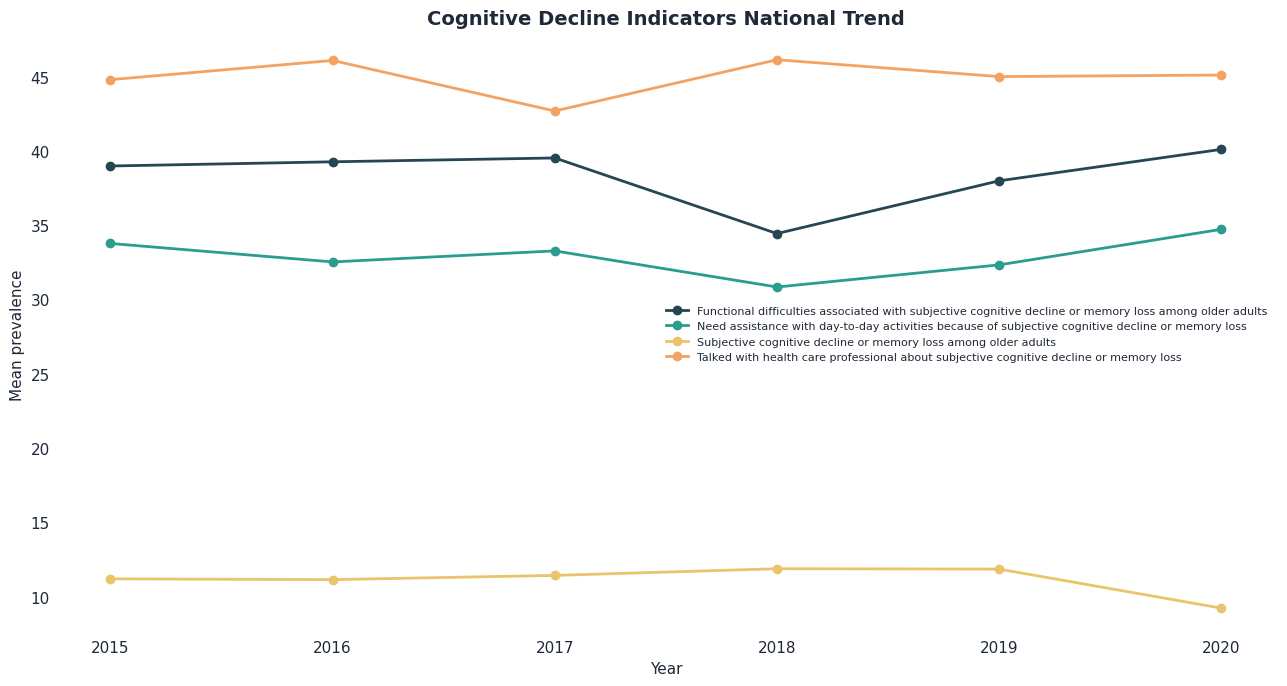

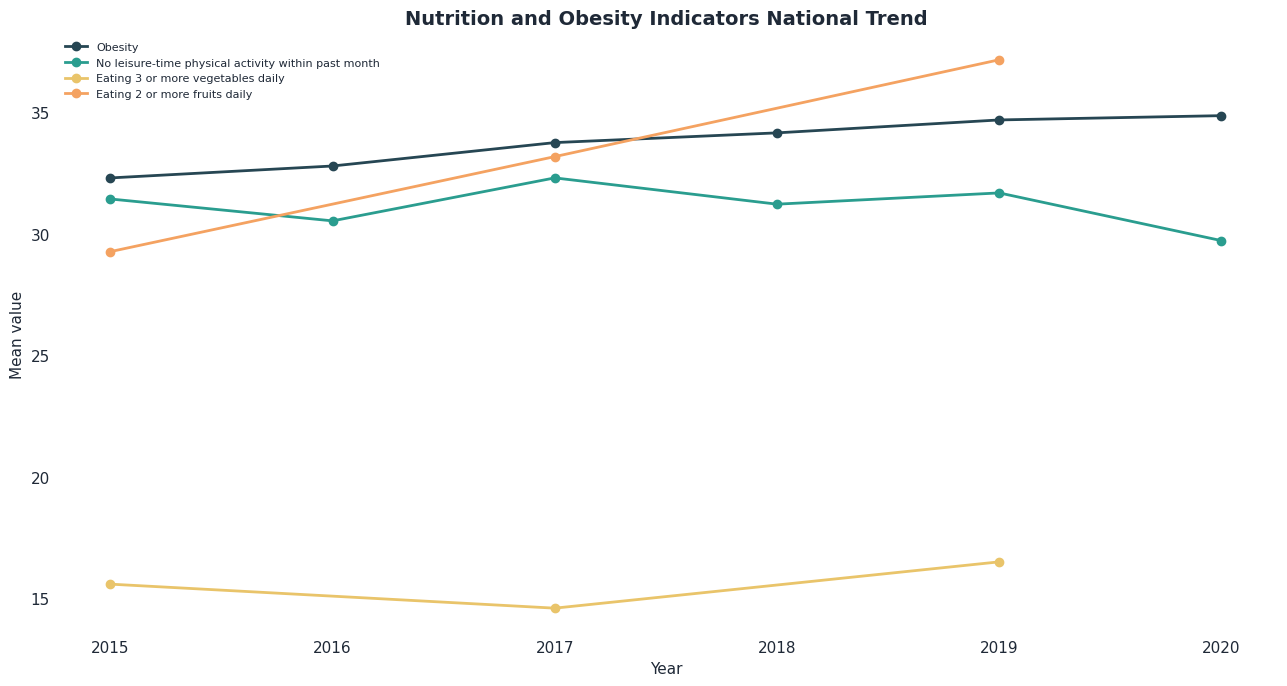

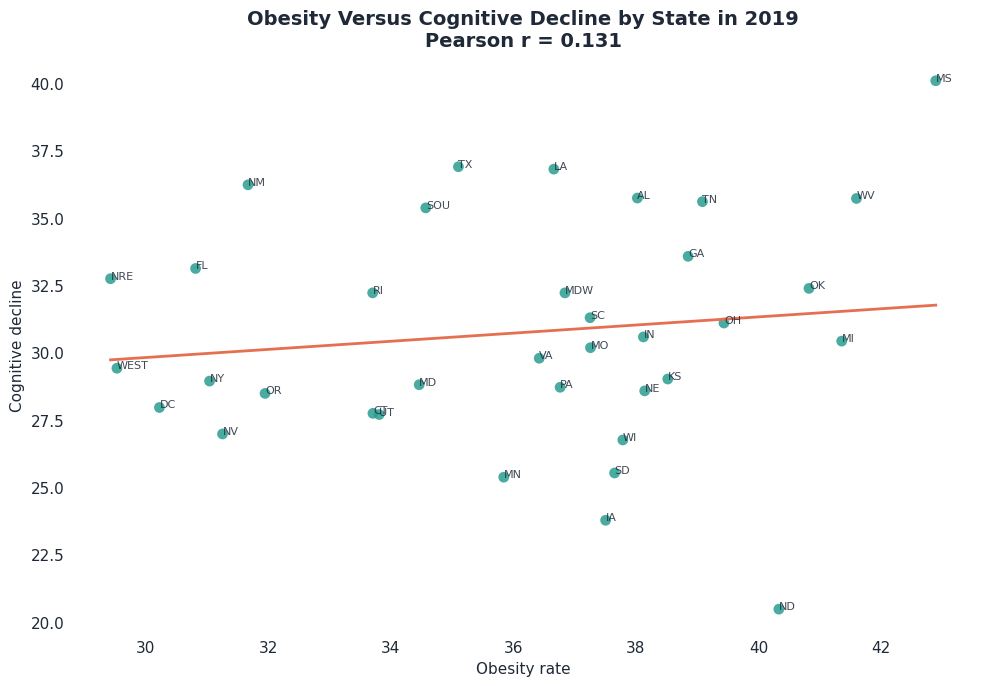

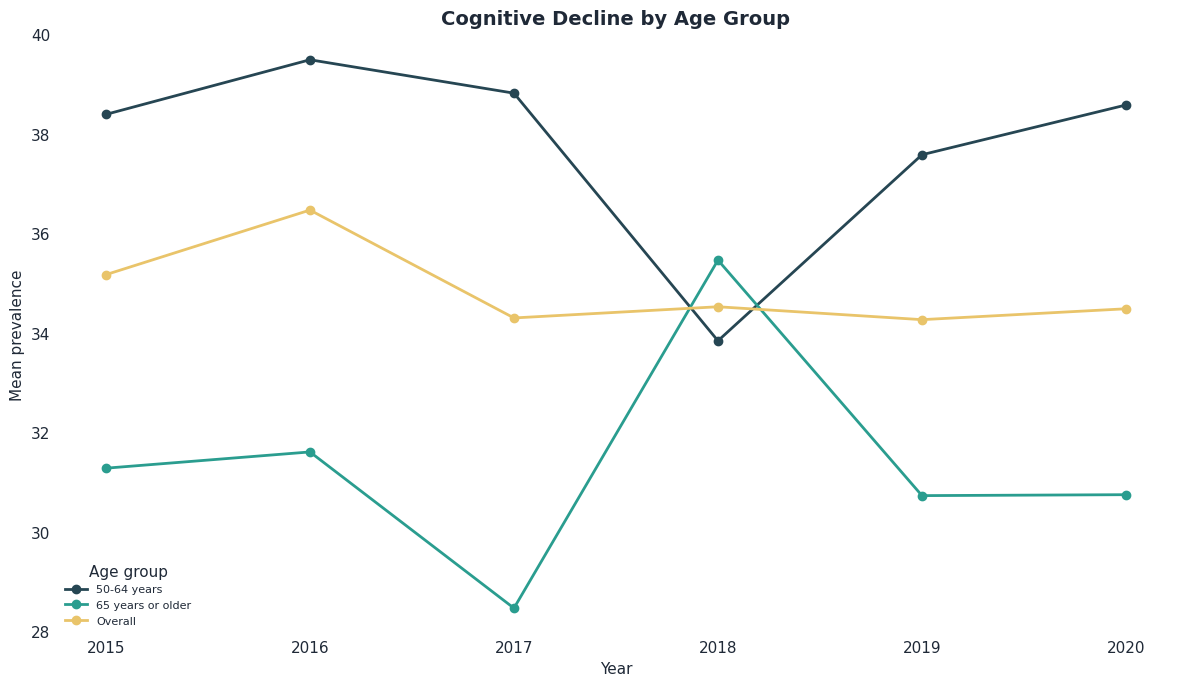

In [8]:
# SECTION 8: CDC POPULATION ANALYSIS

cog_mask = df_cdc["Class"] == "Cognitive Decline"
nutr_mask = df_cdc["Class"] == "Nutrition/Physical Activity/Obesity"

df_cog = df_cdc[cog_mask].copy()
df_nutr = df_cdc[nutr_mask].copy()

# 8.1 Cognitive decline trend
state_cog = (
    df_cog[df_cog["LocationAbbr"] != "US"]
    .groupby(["YearStart", "Topic"])["Data_Value"]
    .mean()
    .reset_index()
)

topics = state_cog["Topic"].value_counts().head(6).index.tolist()
state_cog_top = state_cog[state_cog["Topic"].isin(topics)]

fig, ax = plt.subplots(figsize=(13, 7))
for i, topic in enumerate(topics):
    subset = state_cog_top[state_cog_top["Topic"] == topic]
    ax.plot(subset["YearStart"], subset["Data_Value"],
            marker="o", linewidth=2, label=topic, color=C_SEQ[i % len(C_SEQ)])

ax.set_title("Cognitive Decline Indicators National Trend")
ax.set_xlabel("Year")
ax.set_ylabel("Mean prevalence")
ax.legend(loc="best", fontsize=8)
save_fig("16_cdc_cognitive_decline_trend", fig)

# 8.2 Nutrition and obesity trend
nutr_trend = (
    df_nutr[df_nutr["LocationAbbr"] != "US"]
    .groupby(["YearStart", "Topic"])["Data_Value"]
    .mean()
    .reset_index()
)

nutr_topics = nutr_trend["Topic"].value_counts().head(5).index.tolist()
nutr_trend_top = nutr_trend[nutr_trend["Topic"].isin(nutr_topics)]

fig, ax = plt.subplots(figsize=(13, 7))
for i, topic in enumerate(nutr_topics):
    subset = nutr_trend_top[nutr_trend_top["Topic"] == topic]
    ax.plot(subset["YearStart"], subset["Data_Value"],
            marker="o", linewidth=2, label=topic, color=C_SEQ[i % len(C_SEQ)])

ax.set_title("Nutrition and Obesity Indicators National Trend")
ax.set_xlabel("Year")
ax.set_ylabel("Mean value")
ax.legend(loc="best", fontsize=8)
save_fig("17_cdc_nutrition_trend", fig)

# 8.3 Obesity versus cognitive decline at state level
obesity_q = "Obesity"
cog_q = "Subjective cognitive decline"

state_obesity = (
    df_nutr[
        df_nutr["Topic"].str.contains(obesity_q, case=False, na=False)
        & (df_nutr["LocationAbbr"] != "US")
        & (df_nutr["YearStart"] == 2019)
    ]
    .groupby("LocationAbbr")["Data_Value"]
    .mean()
    .reset_index()
    .rename(columns={"Data_Value": "obesity_pct"})
)

state_cog_2019 = (
    df_cog[
        df_cog["Topic"].str.contains(cog_q, case=False, na=False)
        & (df_cog["LocationAbbr"] != "US")
        & (df_cog["YearStart"] == 2019)
    ]
    .groupby("LocationAbbr")["Data_Value"]
    .mean()
    .reset_index()
    .rename(columns={"Data_Value": "cognitive_decline_pct"})
)

merged_states = pd.merge(state_obesity, state_cog_2019, on="LocationAbbr")

if len(merged_states) > 5:
    corr_val = merged_states["obesity_pct"].corr(merged_states["cognitive_decline_pct"])

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(
        merged_states["obesity_pct"],
        merged_states["cognitive_decline_pct"],
        s=60,
        color="#2A9D8F",
        alpha=0.85,
        edgecolor="none",
    )

    for _, row in merged_states.iterrows():
        ax.text(row["obesity_pct"], row["cognitive_decline_pct"],
                row["LocationAbbr"], fontsize=8, alpha=0.85)

    slope, intercept = np.polyfit(
        merged_states["obesity_pct"],
        merged_states["cognitive_decline_pct"],
        1,
    )
    x_line = np.linspace(merged_states["obesity_pct"].min(), merged_states["obesity_pct"].max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color="#E76F51", linewidth=2)

    ax.set_title(f"Obesity Versus Cognitive Decline by State in 2019\nPearson r = {corr_val:.3f}")
    ax.set_xlabel("Obesity rate")
    ax.set_ylabel("Cognitive decline")
    save_fig("18_obesity_vs_cognitive_decline", fig)

# 8.4 Age group cognitive decline trend
age_cog = (
    df_cog[
        (df_cog["LocationAbbr"] == "US")
        & (df_cog["StratificationCategory1"] == "Age Group")
    ]
    .groupby(["YearStart", "Stratification1"])["Data_Value"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
age_groups = age_cog["Stratification1"].dropna().unique().tolist()

for i, age_group in enumerate(age_groups):
    subset = age_cog[age_cog["Stratification1"] == age_group]
    ax.plot(subset["YearStart"], subset["Data_Value"],
            marker="o", linewidth=2, label=age_group, color=C_SEQ[i % len(C_SEQ)])

ax.set_title("Cognitive Decline by Age Group")
ax.set_xlabel("Year")
ax.set_ylabel("Mean prevalence")
ax.legend(title="Age group", fontsize=8)
save_fig("19_cdc_agegroup_cognitive_decline", fig)

df_cog.to_csv(f"{DATA_DIR}/cdc_cognitive_decline.csv", index=False)
df_nutr.to_csv(f"{DATA_DIR}/cdc_nutrition_obesity.csv", index=False)

## 8. Final results summary

The latest completed run produced the following model level results:

| Result | Value |
|---|---:|
| Full feature model test accuracy | 0.7960 |
| Full feature model macro F1 | 0.6734 |
| TRE feature model macro F1 | 0.6858 |
| Full feature count | 351 |
| TRE feature count | 20 |
| Five fold CV macro F1 for full features | 0.6806 ± 0.0124 |

The TRE feature model retained comparable performance while using only 20 features. CN, LMCI, and AD were separated more clearly than SMC. SMC remained the most difficult class, which is consistent with its smaller sample size and more subjective clinical definition.

In [9]:
# SECTION 9: SUMMARY TABLE AND EXPORTS

summary = pd.DataFrame({
    "Component": [
        "Dataset 1 ADNI",
        "Dataset 2 CDC BRFSS",
        "XGBoost Full Feature Model",
        "XGBoost TRE Feature Model",
        "5 Fold CV Full Features",
        "KMeans Clusters",
        "UMAP Embedding",
    ],
    "Detail": [
        f"{len(df_adni):,} patients | 5 stages | {X.shape[1]} features after preprocessing",
        f"{len(df_cdc):,} rows | population healthy aging indicators",
        f"Test Accuracy: {acc:.4f} | Macro F1: {f1:.4f}",
        f"Macro F1: {f1_tre:.4f} | {len(TRE_FEATURES)} TRE relevant features",
        f"Mean F1: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}",
        f"{N_CLUSTERS} clusters | TRE responder phenotyping",
        "2D embedding | n_neighbors=15 | min_dist=0.1",
    ],
    "TRE relevance": [
        "FDG PET, hippocampus, entorhinal, cognition, memory, age, and ApoE4 are direct analysis targets",
        "Provides population context for diet, obesity, aging, and cognitive decline",
        "Tests whether full clinical feature space can stage AD diagnosis",
        "Tests whether TRE relevant biomarkers retain most of the diagnostic signal",
        "Checks model stability under stratified resampling",
        "Suggests potential metabolic cognitive phenotype groups",
        "Visualizes patient level phenotype structure",
    ],
})

summary.to_csv(f"{DATA_DIR}/analysis_summary.csv", index=False)

print("=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)
print(summary.to_string(index=False))
print(f"\nAll outputs saved to {OUTPUT_DIR}/")
print(f"Figures : {FIG_DIR}/")
print(f"Models  : {MODEL_DIR}/")
print(f"Data    : {DATA_DIR}/")
summary

ANALYSIS COMPLETE
                 Component                                                       Detail                                                                                   TRE relevance
            Dataset 1 ADNI 1,737 patients | 5 stages | 351 features after preprocessing FDG PET, hippocampus, entorhinal, cognition, memory, age, and ApoE4 are direct analysis targets
       Dataset 2 CDC BRFSS           214,462 rows | population healthy aging indicators                     Provides population context for diet, obesity, aging, and cognitive decline
XGBoost Full Feature Model                     Test Accuracy: 0.7960 | Macro F1: 0.6734                                Tests whether full clinical feature space can stage AD diagnosis
 XGBoost TRE Feature Model                  Macro F1: 0.6858 | 20 TRE relevant features                      Tests whether TRE relevant biomarkers retain most of the diagnostic signal
   5 Fold CV Full Features                                    

,Component,Detail,TRE relevance
0,Dataset 1 ADNI,"1,737 patients | 5 stages | 351 features after...","FDG PET, hippocampus, entorhinal, cognition, m..."
1,Dataset 2 CDC BRFSS,"214,462 rows | population healthy aging indica...","Provides population context for diet, obesity,..."
2,XGBoost Full Feature Model,Test Accuracy: 0.7960 | Macro F1: 0.6734,Tests whether full clinical feature space can ...
3,XGBoost TRE Feature Model,Macro F1: 0.6858 | 20 TRE relevant features,Tests whether TRE relevant biomarkers retain m...
4,5 Fold CV Full Features,Mean F1: 0.6806 ± 0.0124,Checks model stability under stratified resamp...
5,KMeans Clusters,4 clusters | TRE responder phenotyping,Suggests potential metabolic cognitive phenoty...
6,UMAP Embedding,2D embedding | n_neighbors=15 | min_dist=0.1,Visualizes patient level phenotype structure


## Conclusion

The main finding is that the TRE relevant feature set achieved comparable macro F1 performance to the full clinical feature model while using far fewer variables. In the latest weighted run, the full model used 351 features and reached a macro F1 score of 0.6734, while the TRE focused model used only 20 features and reached a macro F1 score of 0.6858.

This result suggests that a compact group of metabolic, cognitive, memory, structural brain, demographic, and genetic markers contains substantial disease staging signal in this dataset. Features such as FDG PET, cognitive assessment scores, memory scores, hippocampal volume, entorhinal volume, age, education, and ApoE4 risk are therefore useful for building a more interpretable staging workflow.

The model performed better for clinically clearer groups such as CN, LMCI, and AD. SMC remained the weakest class, which is expected because it has the smallest sample size and represents a more subjective and clinically overlapping stage. Class weighting was included to reduce the effect of class imbalance, but the SMC result should still be interpreted carefully.

Overall, the results support the use of a compact TRE relevant biomarker panel as an interpretable alternative to a much larger clinical feature matrix for Alzheimer's disease staging.